Ноутбук сделан для петпроекта - credit scoring (бинарная классификация давать/не давать кредит - столбец SeriousDlqin2yrs)

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
seed=3010
where_is_data='/kaggle/input/GiveMeSomeCredit/cs-training.csv'

In [11]:
data=pd.read_csv(where_is_data, index_col='Unnamed: 0') #почему-то в данных не было название колонки с id

In [12]:
data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [14]:
data.nunique()

SeriousDlqin2yrs                             2
RevolvingUtilizationOfUnsecuredLines    125728
age                                         86
NumberOfTime30-59DaysPastDueNotWorse        16
DebtRatio                               114194
MonthlyIncome                            13594
NumberOfOpenCreditLinesAndLoans             58
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
dtype: int64

Посмотрим на статистику по данным

In [15]:
data.describe(include='all')

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Видно, что в некоторых столбцах есть пропущенные значения. Пока что удалим их

In [16]:
data1_0=data.dropna()

In [17]:
data1_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120269 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      120269 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  120269 non-null  float64
 2   age                                   120269 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  120269 non-null  int64  
 4   DebtRatio                             120269 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       120269 non-null  int64  
 7   NumberOfTimes90DaysLate               120269 non-null  int64  
 8   NumberRealEstateLoansOrLines          120269 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  120269 non-null  int64  
 10  NumberOfDependents                    120269 non-null  float64
dtypes: fl

отделяем train/test выборку

In [18]:
data_train, data_test = train_test_split(data1_0,test_size=0.2, shuffle=True, random_state=seed,stratify=data1_0['SeriousDlqin2yrs'])

In [19]:
y_test,x_test=data_test['SeriousDlqin2yrs'], data_test.drop('SeriousDlqin2yrs',axis=1)
y_train,X_train=data_train['SeriousDlqin2yrs'], data_train.drop('SeriousDlqin2yrs',axis=1)

Для начала сделаем baseline - logistic regression

In [20]:
from sklearn.linear_model import LogisticRegression
base_model=LogisticRegression(random_state=seed,max_iter=10**3)

In [21]:
base_model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=3010)

проверим, что у нас получилось

In [22]:
baseline_res=base_model.score(x_test,y_test)

In [23]:
print(f'результат baseline: {baseline_res}')

результат baseline: 0.9316953521243868


Получаем, что самые значимые признаки -  NumberOfTime60-89DaysPastDueNotWorse, NumberOfTime30-59DaysPastDueNotWorse

мы уже получили высокий результат. Попробуем его увеличить разными методами:
1) поработаем с данными(пронормрую данные и т.д.)
2) попробуем другие модели (напримре catboost) 

Для начала пронормируем данные

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
scaler.fit(X_train)

StandardScaler()

In [26]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled= scaler.transform(x_test)

Теперь пробуем обучить на новых данных

In [27]:
scaled_base_model=LogisticRegression(random_state=seed)
scaled_base_model.fit(X_train_scaled,y_train)
print(scaled_base_model.score(X_test_scaled,y_test))

0.9316537789972562


Результат не сильно увеличился. Посмотрим на веса модели, чтобы посмотреть на важность признаков

In [28]:
for i, coef in enumerate(scaled_base_model.coef_[0]):
    print(f"Признак {X_train.columns[i]}: вес = {coef:.4f}")

Признак RevolvingUtilizationOfUnsecuredLines: вес = -0.0245
Признак age: вес = -0.3567
Признак NumberOfTime30-59DaysPastDueNotWorse: вес = 1.7483
Признак DebtRatio: вес = -0.0838
Признак MonthlyIncome: вес = -0.6658
Признак NumberOfOpenCreditLinesAndLoans: вес = -0.0323
Признак NumberOfTimes90DaysLate: вес = 1.4860
Признак NumberRealEstateLoansOrLines: вес = 0.1019
Признак NumberOfTime60-89DaysPastDueNotWorse: вес = -3.0816
Признак NumberOfDependents: вес = 0.1200


Видим, что наибольший вес у признаков:

 NumberOfTime30-59DaysPastDueNotWorse - Number of times borrower has been 30-59 days past due but no worse in the last 2 years.
 
 NumberOfTimes90DaysLate - Number of times borrower has been 90 days or more past due.

 NumberOfTime60-89DaysPastDueNotWorse - Number of times borrower has been 60-89 days past due but no worse in the last 2 years.

что логично - если заёмщик уже просрачивал платёж, то, наверное, давать ему кредит не стоит

Теперь попробуем использовать catboost

In [29]:
from catboost import CatBoostClassifier


cat_boost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
)

In [30]:
#для деревьев не нужна нормализация, поэтому используем изначальные данные
cat_boost_model.fit(X_train, y_train)

0:	learn: 0.6187527	total: 68.6ms	remaining: 6.79s
1:	learn: 0.5577925	total: 79ms	remaining: 3.87s
2:	learn: 0.5075773	total: 87.3ms	remaining: 2.82s
3:	learn: 0.4645813	total: 96.4ms	remaining: 2.31s
4:	learn: 0.4286656	total: 105ms	remaining: 1.99s
5:	learn: 0.3976531	total: 113ms	remaining: 1.77s
6:	learn: 0.3709757	total: 121ms	remaining: 1.61s
7:	learn: 0.3478103	total: 129ms	remaining: 1.48s
8:	learn: 0.3281114	total: 136ms	remaining: 1.38s
9:	learn: 0.3109242	total: 145ms	remaining: 1.3s
10:	learn: 0.2957583	total: 152ms	remaining: 1.23s
11:	learn: 0.2823188	total: 160ms	remaining: 1.17s
12:	learn: 0.2708020	total: 168ms	remaining: 1.12s
13:	learn: 0.2609487	total: 176ms	remaining: 1.08s
14:	learn: 0.2521734	total: 184ms	remaining: 1.04s
15:	learn: 0.2445361	total: 191ms	remaining: 1s
16:	learn: 0.2378717	total: 199ms	remaining: 970ms
17:	learn: 0.2321787	total: 206ms	remaining: 938ms
18:	learn: 0.2269576	total: 214ms	remaining: 913ms
19:	learn: 0.2223620	total: 222ms	remaining

In [31]:
y_pred=cat_boost_model.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score

print(f'catboost accuracy: {accuracy_score(y_test,y_pred)}')

catboost accuracy: 0.9347717635320529


Подозрительно, что у нас такой высокий результат, давайте попробуем f1 метрику

In [33]:
from sklearn.metrics import f1_score

print(f'catboost f1: {f1_score(y_test,y_pred)}')

catboost f1: 0.2897238569488456


резльтат довольно низский. Это может быть связано с неравномерным распределением классов. Давайте посмотрим

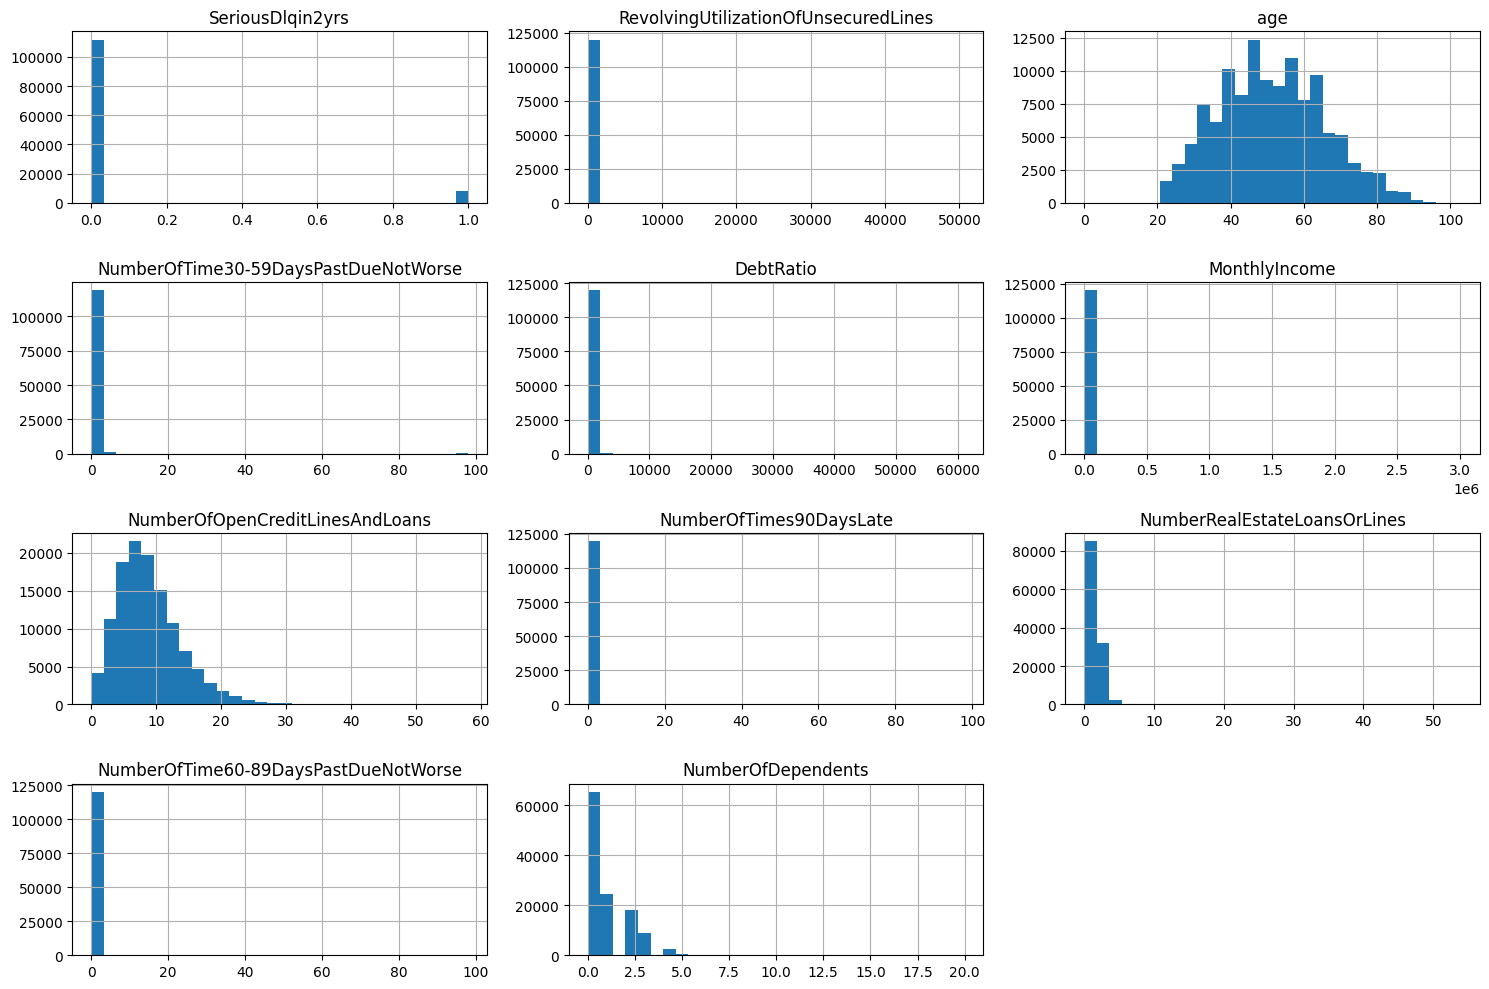

In [34]:
import matplotlib.pyplot as plt


data1_0.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


видно, что большинство столбцов распределены не нормально, в том числе и таргет

In [35]:
print('значение 0 в таргете занимает:', 100*len(data1_0[data1_0['SeriousDlqin2yrs']==0])/len(data),'%')

значение 0 в таргете занимает: 74.608 %


проверим f1-метрику на линейной регрессии

In [36]:
y_pred_scaled=scaled_base_model.predict(X_test_scaled)
print(f'f1 линейной модели {f1_score(y_test,y_pred_scaled)}')

f1 линейной модели 0.07223476297968397


Посмотрим ещё на roc_auc у линейной модели и catboost

In [37]:
from sklearn.metrics import roc_auc_score

In [38]:
y_pred_proba_catboost_all=cat_boost_model.predict_proba(x_test)
y_pred_proba_catboost=[x[1] for x in y_pred_proba_catboost_all]#оставляем только вероятности первого класса

In [39]:
print(f'ROC_AUC catboost: {roc_auc_score(y_test,y_pred_proba_catboost)}')

ROC_AUC catboost: 0.8592333435279773


In [40]:
y_pred_proba_linear_all=scaled_base_model.predict_proba(x_test)
y_pred_proba_linear=[x[1] for x in y_pred_proba_linear_all]#оставляем только вероятности первого класса
print(f'ROC_AUC linear regression:{roc_auc_score(y_test, y_pred_proba_linear)}')

ROC_AUC linear regression:0.4911743874183389


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ROC-AUC показал, что мы качесвто catboost больше. Посмторим на полное распределение данных, возможно, когда мы выбрасывали данные из data, мы сильно изменили распределение.

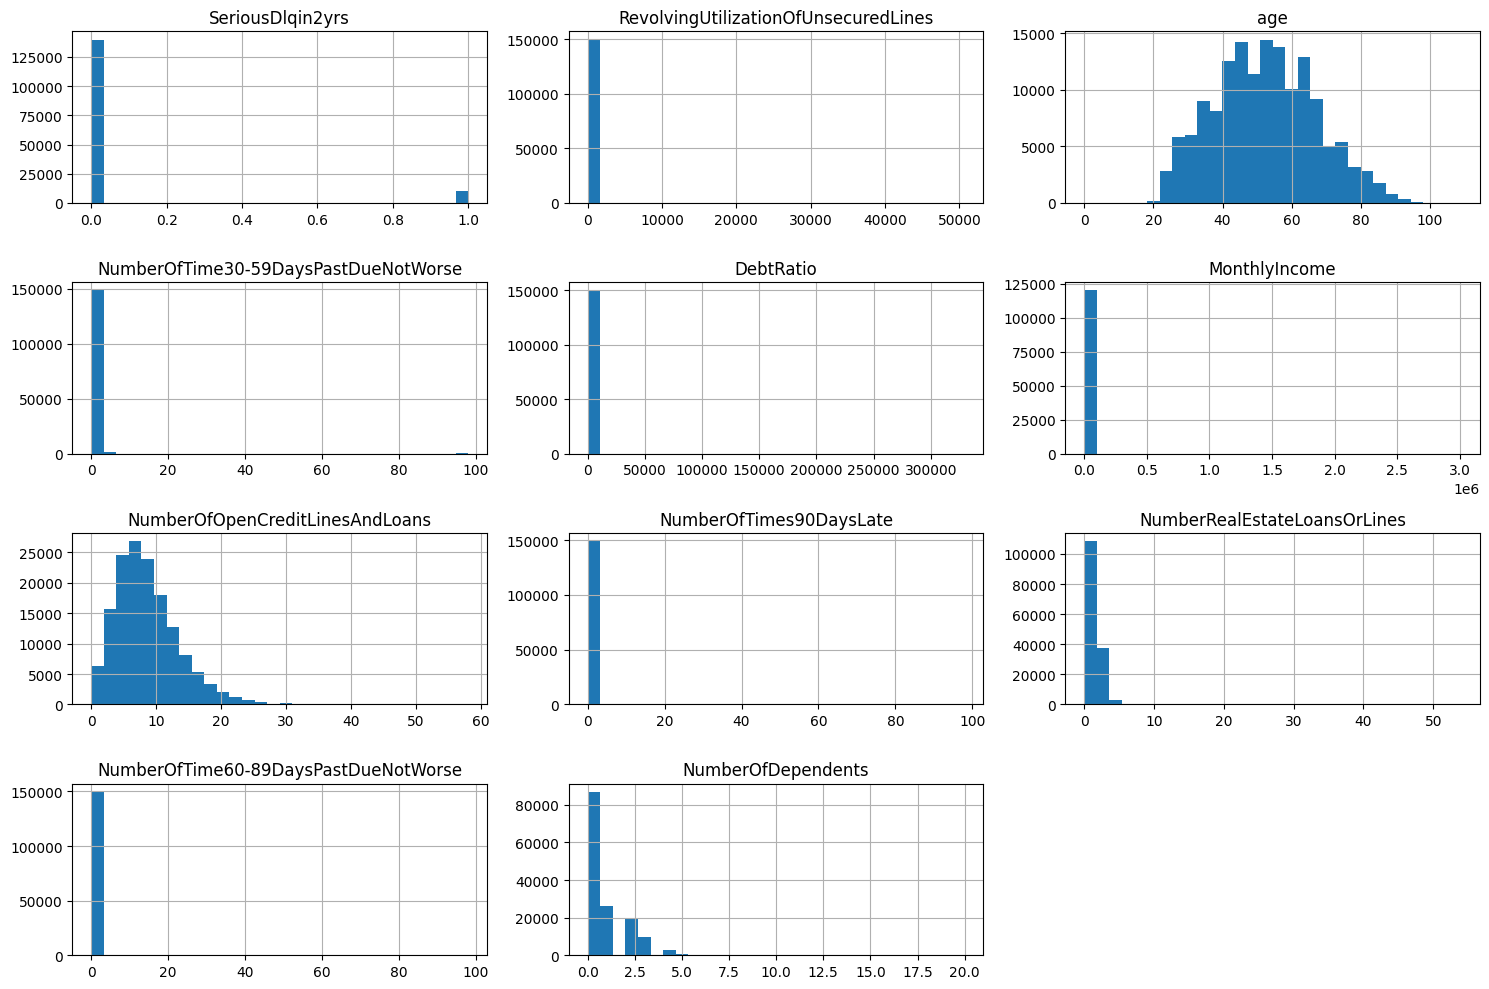

In [41]:
data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Из графиков видно, что, выбросив данные мы не сильно изменили выборку